# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---


### AI Usage Disclosure

Claude (Anthropic) was used in this notebook as support for code debugging/fixes
and to help draft the explanatory code comments and markdown notes throughout.

---

## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [2]:
# --- 1. Setup ---
import os                                  # filesystem paths, checking if checkpoints exist
import json                                # save/load training history alongside checkpoints
import random                              # seed Python's own RNG
import numpy as np                         # seed NumPy's RNG, general array ops
import torch                               # core tensor/autograd library
import torch.nn as nn                      # neural network layers (Conv2d, Linear, ...)
import torch.nn.functional as F            # functional ops (relu, dropout, cross_entropy, ...)
import torchvision                         # datasets (CIFAR10/100) and transforms
from torchvision import transforms         # image preprocessing pipeline building blocks
from torch.utils.data import Subset, random_split  # dataset slicing/splitting utilities
import matplotlib.pyplot as plt            # plotting

# Fix every source of randomness we control, so that dataset splits and
# training runs are reproducible across notebook restarts.
SEED = 42
torch.manual_seed(SEED)      # seeds PyTorch's RNG (weight init, dropout masks, shuffling)
np.random.seed(SEED)         # seeds NumPy's RNG
random.seed(SEED)            # seeds Python's built-in random module

# Use the GPU if available (works transparently with ROCm on AMD GPUs too,
# since PyTorch exposes the same torch.cuda.* API regardless of vendor).
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
class CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        # NOTE: manual on/off switch checked explicitly in forward() below --
        # unlike nn.Dropout, calling model.eval() does NOT disable it
        # automatically. Must be set to False by hand for standard eval.
        self.dropout = dropout

        # Five convolutional layers. Channels grow (3->32->64->128->128->256),
        # spatial size shrinks only twice (conv4/conv5 use stride=2): 32x32 -> 8x8.
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)               # 32x32, 3->32 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)              # 32x32, 32->64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)             # 32x32, 64->128
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # 32x32 -> 16x16 (downsample)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # 16x16 -> 8x8 (downsample)

        self.flatten_dim = 256 * 8 * 8  # 256 channels x 8x8 = 16384 features once flattened
        self.fc1 = nn.Linear(self.flatten_dim, 256)   # 16384 -> 256
        self.fc2 = nn.Linear(256, 128)                 # 256 -> 128
        self.fc3 = nn.Linear(128, 10)                  # 128 -> 10 (CIFAR-10 classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # conv + non-linearity, spatial size unchanged
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))   # this conv already halves spatial size (stride=2)
        x = F.relu(self.conv5(x))   # halves spatial size again
        x = torch.flatten(x, 1)     # flatten all dims except batch -> shape (batch, 16384)
        if self.dropout:
            # Dropout after each fc activation (default rate p=0.5). training=True
            # by default in F.dropout, so it stays active at inference unless
            # self.dropout is explicitly set to False first.
            x = F.dropout(F.relu(self.fc1(x)))
            x = F.dropout(F.relu(self.fc2(x)))
        else:
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
        x = self.fc3(x)   # raw logits, no activation (softmax applied later, outside the model)
        return x

In [4]:
# --- 3. ID dataset: CIFAR-10, with train/val/test split ---
# Two separate, coexisting transforms and train loaders (plain vs augmented),
# so both versions stay available and reproducible at any time -- nothing
# gets overwritten, no matter which one you train/retrain later.
batch_size = 128

# Training transform: augmentation, then tensor + normalize to [-1, 1].
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),        # pad 4px, then crop back to 32x32 at a random offset
    transforms.RandomHorizontalFlip(),           # mirror left-right, 50% of the time
    transforms.ToTensor(),                       # PIL Image -> tensor, scaled to [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])
# Evaluation transform: same normalization, NO augmentation -- val/test
# accuracy must be measured on fixed, deterministic input.
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Two "views" of the exact same 50,000 CIFAR-10 training images -- same
# files, same order, only the transform attached differs.
id_train_full_aug = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
id_train_full_plain = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=eval_transform)
id_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_transform)

val_size = int(0.1 * len(id_train_full_aug))     # 10% held out for validation -> 5000 images
train_size = len(id_train_full_aug) - val_size    # remaining 90% -> 45000 images

# Same seed on both views -> identical index partition either way, only the
# transform differs.
generator = torch.Generator().manual_seed(SEED)
id_train_aug, _ = random_split(id_train_full_aug, [train_size, val_size], generator=generator)
# We discard "_" here (the augmented view's validation slice) -- validation
# must always use the CLEAN version of those images (kept below).

generator2 = torch.Generator().manual_seed(SEED)
id_train_plain, id_val = random_split(id_train_full_plain, [train_size, val_size], generator=generator2)
# id_val (from the plain/clean view) is the one used everywhere as "the" validation set.

# Two independent, coexisting train loaders. shuffle=True: batch order
# shouldn't matter for training. num_workers=4: parallelize data loading
# across CPU cores while the GPU works on the previous batch.
id_train_loader_plain = torch.utils.data.DataLoader(id_train_plain, batch_size=batch_size, shuffle=True, num_workers=4)
id_train_loader_aug = torch.utils.data.DataLoader(id_train_aug, batch_size=batch_size, shuffle=True, num_workers=4)

# shuffle=False: order doesn't matter, and a consistent order helps
# debugging/reproducibility of printed metrics.
id_val_loader = torch.utils.data.DataLoader(id_val, batch_size=batch_size, shuffle=False)
id_test_loader = torch.utils.data.DataLoader(id_test, batch_size=batch_size, shuffle=False)

print(f"ID train (plain): {len(id_train_plain)}, ID train (aug): {len(id_train_aug)}, ID val: {len(id_val)}, ID test: {len(id_test)}")

ID train (plain): 45000, ID train (aug): 45000, ID val: 5000, ID test: 10000


In [5]:
# --- 4. OOD dataset: a "far" subset of CIFAR-100 ---
# We pick CIFAR-100 fine classes with NO semantic overlap with any CIFAR-10
# class (CIFAR-10 = airplane, automobile, bird, cat, deer, dog, frog, horse,
# ship, truck -- i.e. only vehicles and animals). We deliberately avoid all
# CIFAR-100 animal/vehicle classes and pick from clearly unrelated categories
# (flowers, food containers, man-made outdoor structures).
cifar100_full = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=eval_transform)
# eval_transform (no augmentation) here too: OOD images must be preprocessed
# exactly as the model expects real input, not artificially perturbed on
# top of already being OOD.

FAR_OOD_CLASSES = [
    "orchid", "poppy", "rose", "sunflower", "tulip",          # flowers
    "bottle", "bowl", "can", "cup", "plate",                   # food containers
    "bridge", "castle", "house", "road", "skyscraper",         # large man-made outdoor things
]
# class_to_idx maps each CIFAR-100 class NAME to its integer label.
far_ood_indices = [cifar100_full.class_to_idx[c] for c in FAR_OOD_CLASSES]

# Scan every example in the CIFAR-100 test set (10,000 images -- cheap
# enough for a plain loop) and keep only those in our 15 chosen classes.
ood_indices = [i for i, (_, label) in enumerate(cifar100_full) if label in far_ood_indices]
ood_dataset = Subset(cifar100_full, ood_indices)   # a view containing only those images

# --- CORRECTION: split the OOD pool too, mirroring the ID train/val/test split ---
# Every use of OOD data below this point (model comparison in Ex.1, the
# ODIN grid search in Ex.3) picked something (a model, or T/epsilon) by
# looking at OOD scores. Reusing that same OOD data to report a "final"
# AUROC would optimistically bias the number, for the same reason a val
# set can't double as a test set. So we split ood_dataset in half:
# ood_search_* (used for every comparison/selection step) and ood_final_*
# (touched only once, at the very end of Ex.1 and Ex.3, for the honest
# held-out metric).
generator_ood = torch.Generator().manual_seed(SEED)
ood_search_size = int(0.5 * len(ood_dataset))
ood_final_size = len(ood_dataset) - ood_search_size
ood_search_dataset, ood_final_dataset = random_split(
    ood_dataset, [ood_search_size, ood_final_size], generator=generator_ood
)

ood_search_loader = torch.utils.data.DataLoader(ood_search_dataset, batch_size=batch_size, shuffle=False)
ood_final_loader = torch.utils.data.DataLoader(ood_final_dataset, batch_size=batch_size, shuffle=False)

print(f"OOD samples (far subset of CIFAR-100): {len(ood_dataset)} "
      f"-> search: {len(ood_search_dataset)}, final: {len(ood_final_dataset)}")

OOD samples (far subset of CIFAR-100): 1500 -> search: 750, final: 750


**Setup notes:** at this point we have four independent, non-overlapping
pools of ID data: `id_train_*` (used only to fit model weights), `id_val`
(never seen during training, used throughout Exercise 1 and Exercise 3 for
model/hyperparameter *selection* -- i.e. picking the best of the 4 models,
and picking the best ODIN (T, epsilon)), and `id_test` (kept aside,
untouched until it is used for adversarial-robustness evaluation in
Exercise 2 *and* for the final, honest OOD-detection numbers reported at
the end of Exercise 1 and Exercise 3).

On the OOD side, `ood_dataset` (CIFAR-100 images from categories with no
semantic overlap with CIFAR-10) is split the same way, into `ood_search_*`
(paired with `id_val` for every comparison/selection step) and
`ood_final_*` (paired with `id_test`, touched only once, for the final
reported metric). Splitting the OOD pool too, and not just the ID one,
matters here: reusing the same OOD data for both selection and final
reporting would optimistically bias the reported AUROC just as much as
reusing `id_val` in place of `id_test` would.

In [6]:
def train_cnn(train_loader, dropout: bool, epochs: int = 50, lr: float = 1e-4):
    """
    Train a CNN classifier from scratch on the given train_loader, tracking
    validation accuracy every 10 epochs. Returns the trained model plus its
    per-epoch history (saved so a loaded checkpoint can re-print its
    original training progress without retraining).
    """
    model = CNN(dropout=dropout).to(device)         # fresh, randomly-initialized model
    criterion = nn.CrossEntropyLoss()                # standard multi-class classification loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)   # Adam + decoupled weight decay
    history = []                                     # one dict per logged epoch

    for epoch in range(epochs):
        model.train()          # enable training-mode layer behavior
        running_loss = 0.0
        for x, y in train_loader:                 # one batch of images + labels
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()                  # clear gradients from the previous step
            logits = model(x)                       # forward pass -> raw class scores
            loss = criterion(logits, y)             # compare predictions to true labels
            loss.backward()                          # backpropagate: compute gradients
            optimizer.step()                          # update weights using those gradients
            running_loss += loss.item()              # accumulate loss as a plain float

        # Log every 10 epochs (and on the last one) -- checking every epoch
        # would slow things down with no real benefit.
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            model.eval()                              # disable training-mode behavior
            correct, total = 0, 0
            with torch.no_grad():                    # no gradients needed for evaluation
                for x, y in id_val_loader:
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)   # predicted class = highest-scoring logit
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            val_acc = correct / total
            train_loss = running_loss / len(train_loader)   # average loss per batch this epoch
            history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_acc": val_acc})
            print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val acc: {val_acc:.4f}")

    return model, history


def get_model(train_loader, dropout: bool, checkpoint_path: str, epochs: int = 50, lr: float = 1e-4):
    """
    Load the model from checkpoint_path if it already exists (re-printing
    its saved training history for continuity); otherwise train it from
    scratch via train_cnn and save both weights and history. Re-running
    this cell is always safe/cheap after the first successful training.
    """
    model = CNN(dropout=dropout)                              # architecture must match the checkpoint
    history_path = checkpoint_path.replace(".pth", "_history.json")

    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}, loading it.")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))  # load saved weights
        model = model.to(device)
        if os.path.exists(history_path):
            with open(history_path) as f:
                history = json.load(f)
            for h in history:   # re-print the log exactly as it looked the first time
                print(f"Epoch {h['epoch']}/{epochs} - train loss: {h['train_loss']:.4f} - val acc: {h['val_acc']:.4f}")
    else:
        print(f"No checkpoint found at {checkpoint_path}, training from scratch.")
        model, history = train_cnn(train_loader, dropout=dropout, epochs=epochs, lr=lr)
        torch.save(model.state_dict(), checkpoint_path)   # save weights for next time
        with open(history_path, "w") as f:
            json.dump(history, f)                          # save training log alongside them

    return model

In [7]:
# --- 5. Original (no augmentation) ---
# Two models sharing the same (non-augmented) training data, differing only
# in whether dropout regularization is active.
cnn_baseline = get_model(id_train_loader_plain, dropout=False, checkpoint_path="checkpoints/cnn_baseline.pth")
cnn_dropout = get_model(id_train_loader_plain, dropout=True, checkpoint_path="checkpoints/cnn_dropout.pth")

Found existing checkpoint at checkpoints/cnn_baseline.pth, loading it.
Epoch 10/50 - train loss: 0.8133 - val acc: 0.6418
Epoch 20/50 - train loss: 0.1180 - val acc: 0.6386
Epoch 30/50 - train loss: 0.0266 - val acc: 0.6358
Epoch 40/50 - train loss: 0.0325 - val acc: 0.6424
Epoch 50/50 - train loss: 0.0215 - val acc: 0.6338
Found existing checkpoint at checkpoints/cnn_dropout.pth, loading it.
Epoch 10/50 - train loss: 1.1720 - val acc: 0.5774
Epoch 20/50 - train loss: 0.7681 - val acc: 0.6346
Epoch 30/50 - train loss: 0.4557 - val acc: 0.6572
Epoch 40/50 - train loss: 0.2823 - val acc: 0.6594
Epoch 50/50 - train loss: 0.2080 - val acc: 0.6652


In [8]:
# --- 5bis. Augmented variants ---
# Same two configurations, trained on the augmented loader instead, and
# saved under different checkpoint paths so all four combinations stay
# independently available. 100 epochs (vs 50 above): augmentation makes
# each epoch "harder", so more epochs are needed to reach comparable
# convergence -- confirmed by the training logs (see Considerations below).
cnn_baseline_aug = get_model(id_train_loader_aug, dropout=False, checkpoint_path="checkpoints/cnn_baseline_aug.pth", epochs=100)
cnn_dropout_aug = get_model(id_train_loader_aug, dropout=True, checkpoint_path="checkpoints/cnn_dropout_aug.pth", epochs=100)

Found existing checkpoint at checkpoints/cnn_baseline_aug.pth, loading it.
Epoch 10/100 - train loss: 1.2208 - val acc: 0.5820
Epoch 20/100 - train loss: 0.9485 - val acc: 0.6746
Epoch 30/100 - train loss: 0.7890 - val acc: 0.7086
Epoch 40/100 - train loss: 0.6767 - val acc: 0.7410
Epoch 50/100 - train loss: 0.5872 - val acc: 0.7568
Epoch 60/100 - train loss: 0.5179 - val acc: 0.7706
Epoch 70/100 - train loss: 0.4487 - val acc: 0.7756
Epoch 80/100 - train loss: 0.4007 - val acc: 0.7776
Epoch 90/100 - train loss: 0.3543 - val acc: 0.7858
Epoch 100/100 - train loss: 0.3118 - val acc: 0.7862
Found existing checkpoint at checkpoints/cnn_dropout_aug.pth, loading it.
Epoch 10/100 - train loss: 1.3810 - val acc: 0.5372
Epoch 20/100 - train loss: 1.1510 - val acc: 0.6108
Epoch 30/100 - train loss: 1.0108 - val acc: 0.6652
Epoch 40/100 - train loss: 0.9068 - val acc: 0.7080
Epoch 50/100 - train loss: 0.8176 - val acc: 0.7348
Epoch 60/100 - train loss: 0.7455 - val acc: 0.7588
Epoch 70/100 - tra

[baseline] ID scores  -- mean: 0.9397, std: 0.1247
[baseline] OOD scores -- mean: 0.9110, std: 0.1457


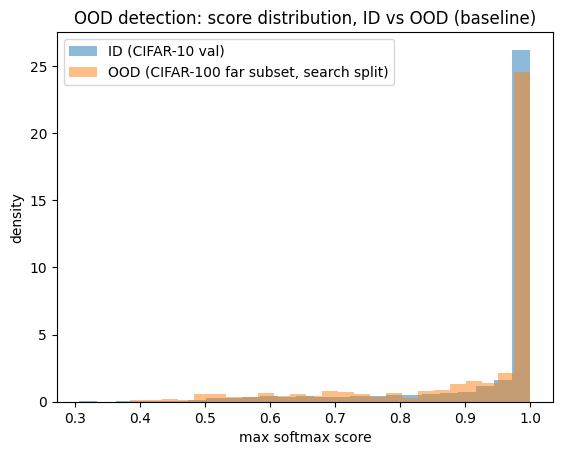

[dropout] ID scores  -- mean: 0.8894, std: 0.1729
[dropout] OOD scores -- mean: 0.7697, std: 0.2150


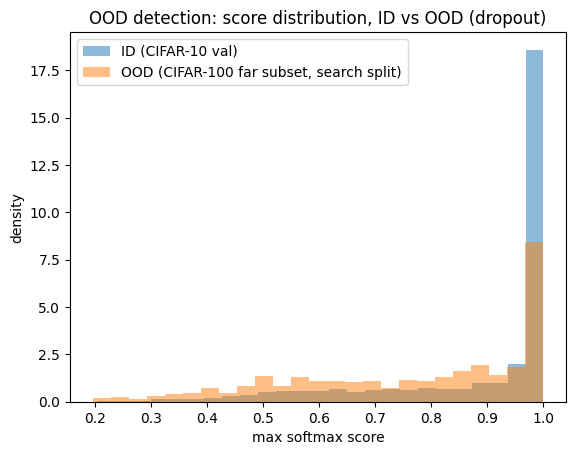

[baseline_aug] ID scores  -- mean: 0.8831, std: 0.1705
[baseline_aug] OOD scores -- mean: 0.7637, std: 0.2051


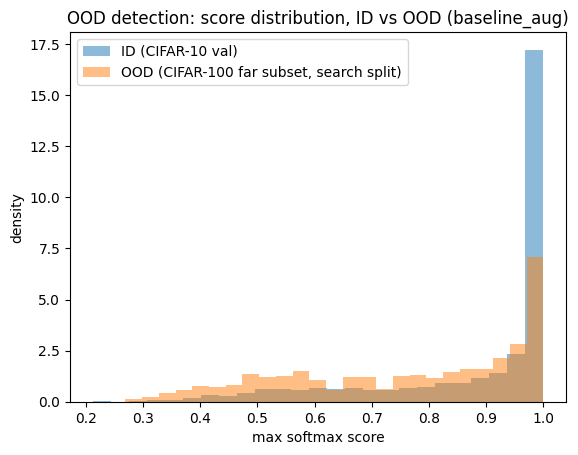

[dropout_aug] ID scores  -- mean: 0.8502, std: 0.1960
[dropout_aug] OOD scores -- mean: 0.6557, std: 0.2213


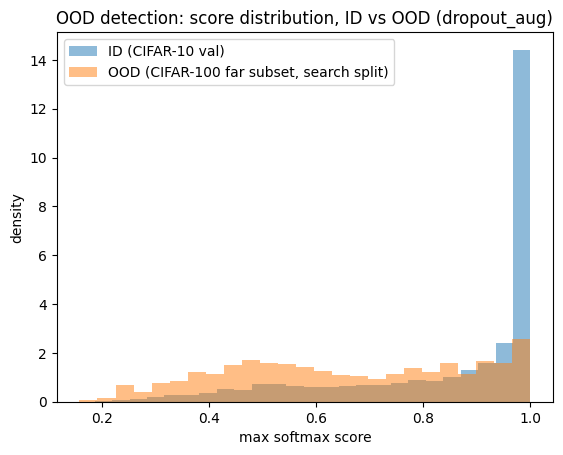

In [9]:
# --- 6. OOD scores for all four models ---
# For each of the 4 trained models, compute a max-softmax confidence score
# on both the ID validation set and the OOD *search* subset, and visualize
# the two score distributions side by side. A well-separated pair of
# histograms means the model's confidence is a useful signal for telling
# ID and OOD samples apart.
# NOTE: this is the MODEL-SELECTION step -- it deliberately uses id_val +
# ood_search (never id_test / ood_final), since those are reserved for the
# unbiased final evaluation once a model has been picked (see below).


def max_logit(logit):
    # Highest raw logit (no softmax). [0]: .max(dim=1) returns (values, indices).
    return logit.max(dim=1)[0]

def max_softmax(logit, T=1.0):
    # Softmax probability of the predicted class. Dividing by T BEFORE the
    # softmax lets us later "flatten" (T>1) or "sharpen" (T<1) it -- this is
    # exactly the temperature scaling ODIN uses in Exercise 3.
    s = F.softmax(logit / T, dim=1)
    return s.max(dim=1)[0]

def compute_scores(data_loader, score_fun, model):
    # Runs `model` over every batch, applies score_fun to the logits, and
    # concatenates all per-image scores into one tensor.
    scores = []
    model.eval()
    with torch.no_grad():         # pure inference, no gradients needed
        for x, y in data_loader:  # y (true label) is unused -- we only need model outputs
            output = model(x.to(device))
            scores.append(score_fun(output))
    return torch.cat(scores)

models = {
    "baseline": cnn_baseline,
    "dropout": cnn_dropout,
    "baseline_aug": cnn_baseline_aug,
    "dropout_aug": cnn_dropout_aug,
}

# Disable the stochastic dropout-at-inference behavior on every model that
# has it, for this standard single-pass evaluation (model.eval() alone isn't
# enough -- see earlier note on CNN.forward() calling F.dropout directly).
for name, model in models.items():
    if hasattr(model, "dropout"):   # true for all 4 -- defensive check
        model.dropout = False        # force standard (non-stochastic) evaluation

scores = {}   # model name -> (id_scores, ood_scores), reused across later cells/exercises
for name, model in models.items():
    id_scores = compute_scores(id_val_loader, max_softmax, model)          # ID: validation split
    ood_scores = compute_scores(ood_search_loader, max_softmax, model)     # OOD: search split
    scores[name] = (id_scores, ood_scores)

    print(f"[{name}] ID scores  -- mean: {id_scores.mean():.4f}, std: {id_scores.std():.4f}")
    print(f"[{name}] OOD scores -- mean: {ood_scores.mean():.4f}, std: {ood_scores.std():.4f}")

    plt.hist(id_scores.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 val)")
    plt.hist(ood_scores.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset, search split)")
    plt.xlabel("max softmax score")
    plt.ylabel("density")
    plt.legend()
    plt.title(f"OOD detection: score distribution, ID vs OOD ({name})")
    plt.show()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


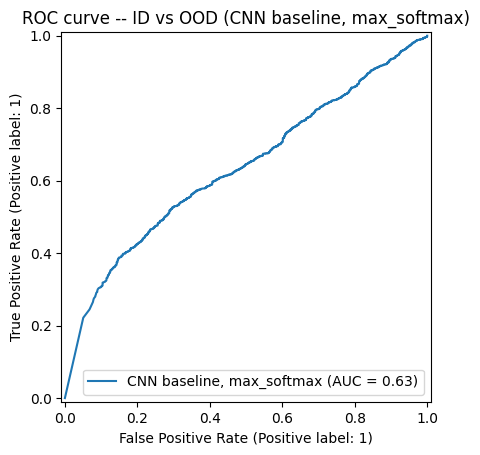

[CNN baseline, max_softmax] AUROC: 0.6344


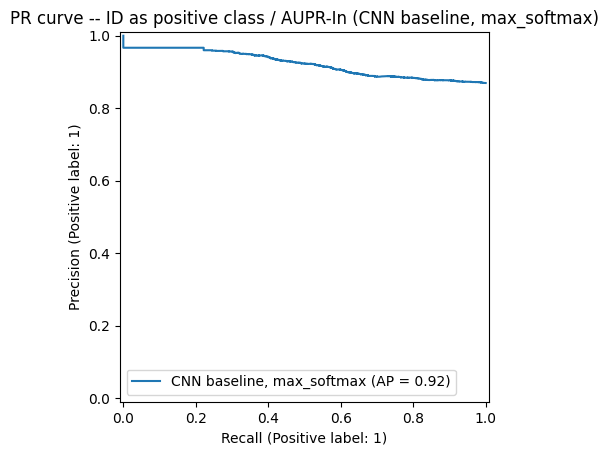

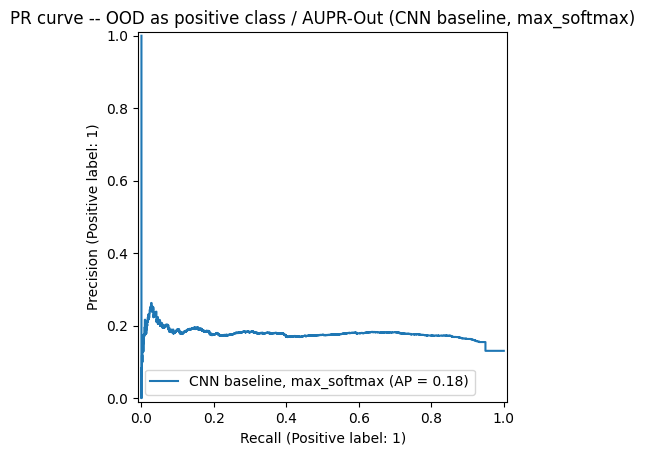

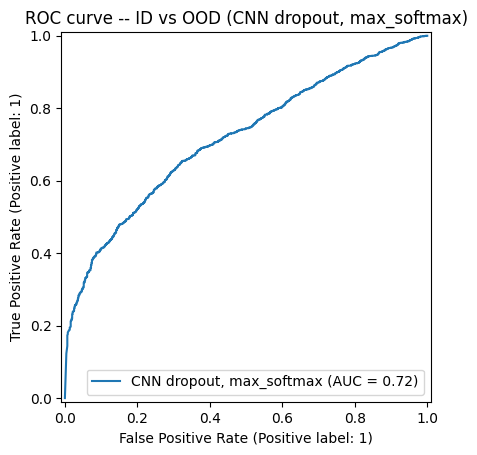

[CNN dropout, max_softmax] AUROC: 0.7177


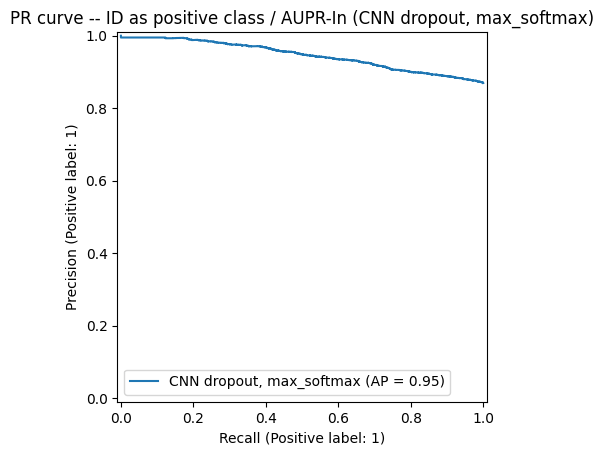

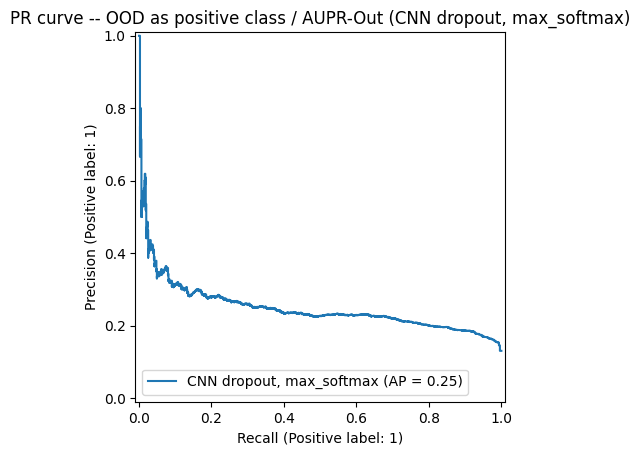

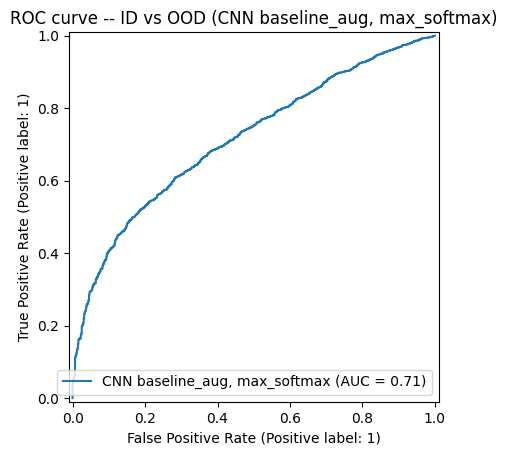

[CNN baseline_aug, max_softmax] AUROC: 0.7143


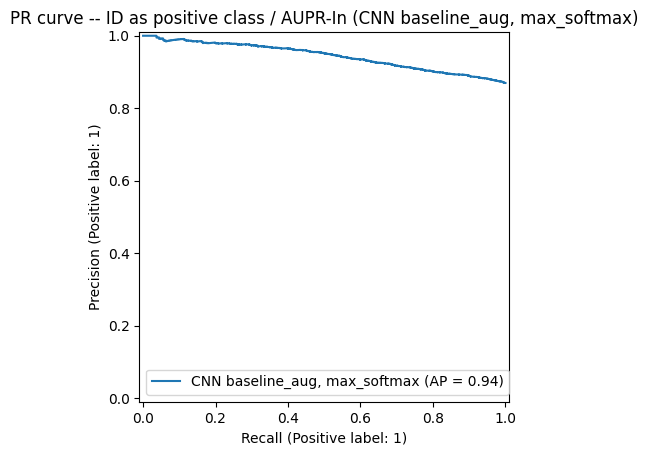

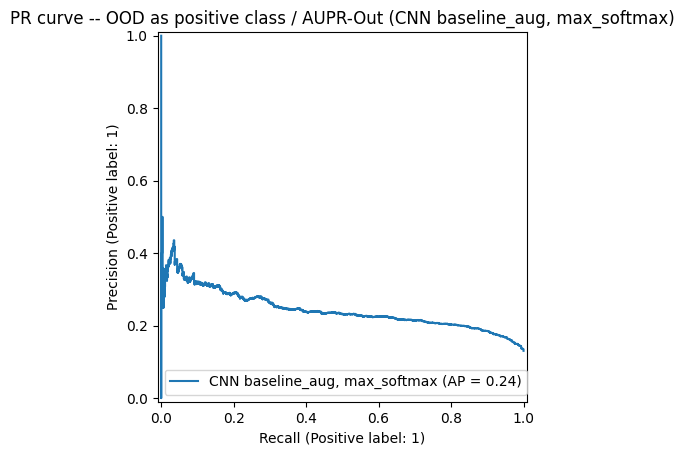

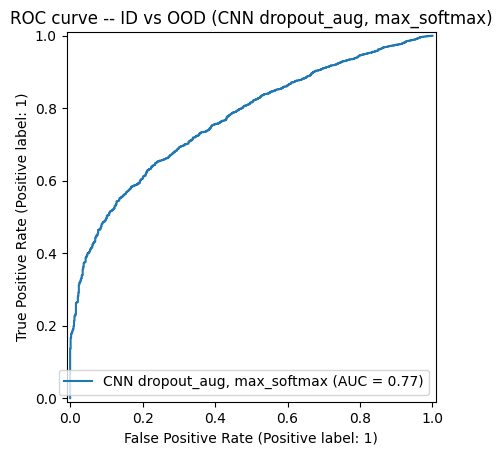

[CNN dropout_aug, max_softmax] AUROC: 0.7695


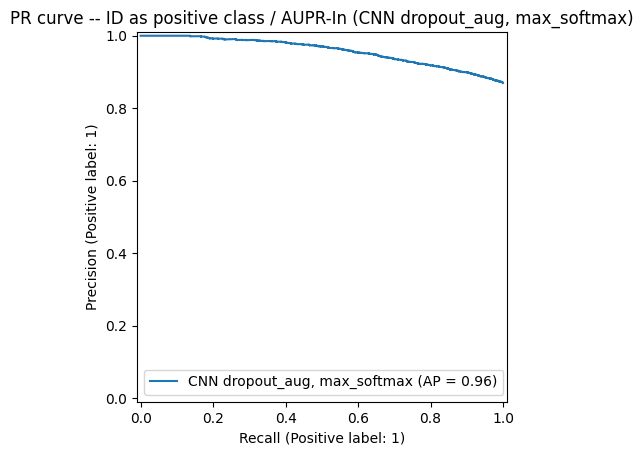

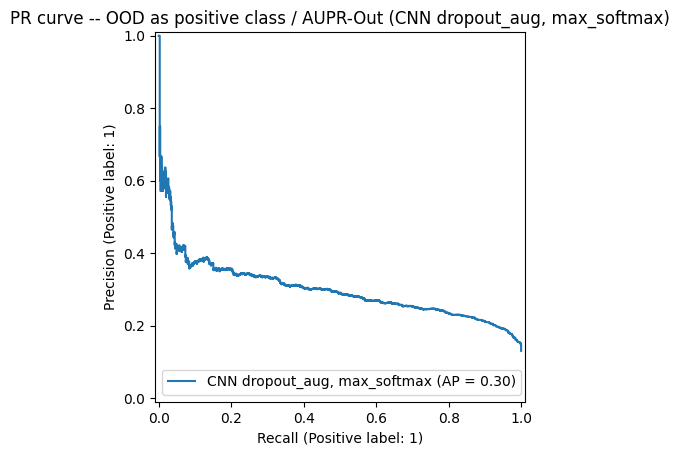

In [10]:
# --- Exercise 1.2: OOD detection metrics (ROC / PR curves) ---
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

def evaluate_ood_detection(id_scores, ood_scores, label=""):
    """
    Given ID and OOD scores (higher score = more confidently in-distribution),
    plots the ROC curve and both PR curves (ID-positive and OOD-positive),
    and prints AUROC.
    """
    id_scores = id_scores.cpu().numpy()
    ood_scores = ood_scores.cpu().numpy()

    # Convention: label 1 = ID, label 0 = OOD. A higher score should mean
    # "more confidently ID" -- exactly what max_softmax/max_logit give us.
    y_true = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    y_score = np.concatenate([id_scores, ood_scores])

    # --- ROC curve: can we tell ID from OOD at all? ---
    RocCurveDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"ROC curve -- ID vs OOD ({label})")
    plt.show()
    print(f"[{label}] AUROC: {roc_auc_score(y_true, y_score):.4f}")

    # --- PR curve, ID as positive class (AUPR-In) ---
    PrecisionRecallDisplay.from_predictions(y_true, y_score, name=label)
    plt.title(f"PR curve -- ID as positive class / AUPR-In ({label})")
    plt.show()

    # --- PR curve, OOD as positive class (AUPR-Out) ---
    # Swapping which class is "positive" also requires flipping the score:
    # a higher score must now mean "more confidently OOD" -- so we negate it.
    # (This is why AUPR-In and AUPR-Out are reported separately in the ODIN
    # paper: unlike ROC, PR curves are NOT symmetric under this swap.)
    y_true_ood = 1 - y_true
    y_score_ood = -y_score
    PrecisionRecallDisplay.from_predictions(y_true_ood, y_score_ood, name=label)
    plt.title(f"PR curve -- OOD as positive class / AUPR-Out ({label})")
    plt.show()


for name, (id_scores, ood_scores) in scores.items():
    evaluate_ood_detection(id_scores, ood_scores, label=f"CNN {name}, max_softmax")

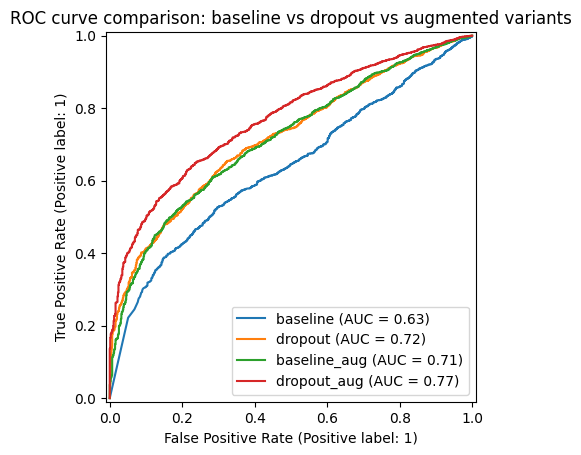

In [11]:
# --- Direct comparison: all four models on the same ROC axes ---
# Overlaying all four curves makes the relative ranking visible at a
# glance, instead of comparing four AUROC numbers printed far apart above.
fig, ax = plt.subplots()
for name, (id_scores, ood_scores) in scores.items():
    y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])
    y_score = np.concatenate([id_scores.cpu().numpy(), ood_scores.cpu().numpy()])
    RocCurveDisplay.from_predictions(y_true, y_score, name=name, ax=ax)
plt.title("ROC curve comparison: baseline vs dropout vs augmented variants")
plt.show()

**Note:** the comparison above (all four models, `id_val` + `ood_search`) is
what determined `dropout_aug` as the best model. The cell below re-evaluates
*only* that chosen model on `id_test` + `ood_final` -- data untouched by the
selection above -- for an unbiased final AUROC.

[dropout_aug, HELD-OUT] ID scores  -- mean: 0.8471, std: 0.1963
[dropout_aug, HELD-OUT] OOD scores -- mean: 0.6302, std: 0.2146


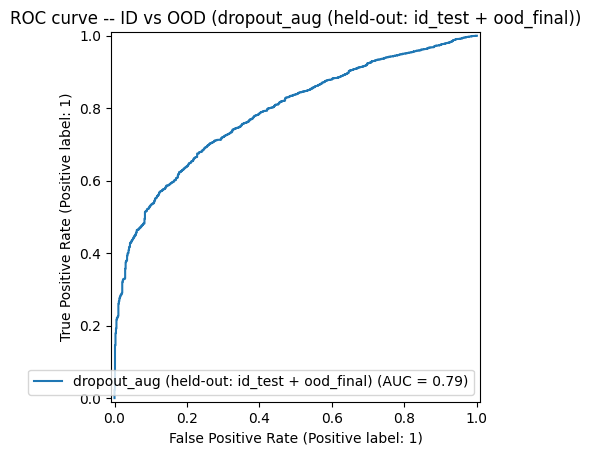

[dropout_aug (held-out: id_test + ood_final)] AUROC: 0.7891


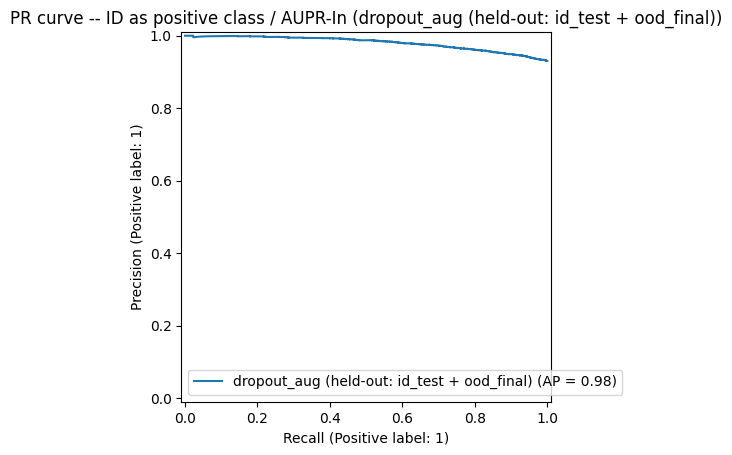

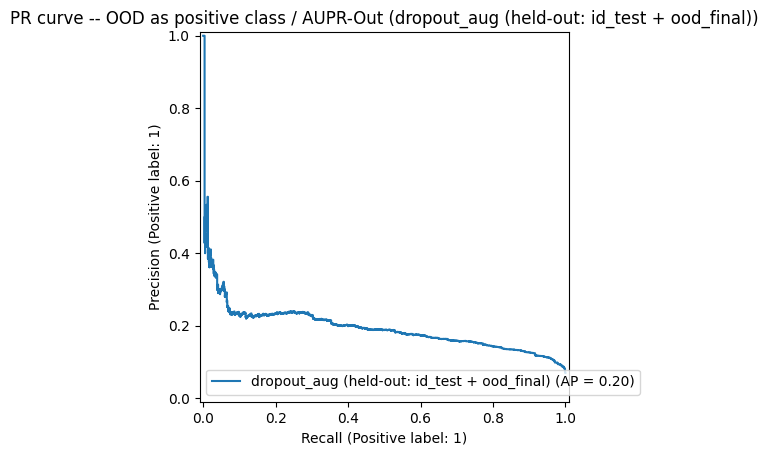

In [12]:
# --- Final, held-out evaluation of the selected model (dropout_aug) ---
# Everything above (the 4-way comparison) used id_val + ood_search, which is
# exactly the data that determined dropout_aug was the best choice. To get
# an unbiased estimate of its OOD detection performance, we evaluate it here
# ONCE on id_test + ood_final -- data that played no role in selecting it.
best_model_name = "dropout_aug"
best_model = models[best_model_name]

id_scores_final = compute_scores(id_test_loader, max_softmax, best_model)
ood_scores_final = compute_scores(ood_final_loader, max_softmax, best_model)

print(f"[{best_model_name}, HELD-OUT] ID scores  -- mean: {id_scores_final.mean():.4f}, std: {id_scores_final.std():.4f}")
print(f"[{best_model_name}, HELD-OUT] OOD scores -- mean: {ood_scores_final.mean():.4f}, std: {ood_scores_final.std():.4f}")

evaluate_ood_detection(id_scores_final, ood_scores_final,
                        label=f"{best_model_name} (held-out: id_test + ood_final)")

## Considerations

Extending training from 50 to 100 epochs for the augmented variants revealed
that our first conclusions were partly premature: `baseline_aug` had already
plateaued at 50 epochs (+0.8pp accuracy with 50 more epochs, and its AUROC
actually *decreased* slightly as the model grew more confident on both ID and
OOD inputs alike), while `dropout_aug` was still clearly under-trained
(+9.1pp accuracy, AUROC improving from 0.741 to 0.770).

With adequate training, the earlier dissociation between "best classifier"
and "best OOD detector" disappears: `dropout_aug` is now the best model on
*both* fronts (79.6% validation accuracy, 0.770 AUROC on the search split,
0.789 on the held-out split), rather than trading one off against the other.
This is a useful reminder that conclusions drawn from an under-trained
checkpoint can be misleading -- what looked like a genuine trade-off was, at
least in part, an artifact of comparing models at different stages of
convergence.

Looking at all four models together, AUROC improves with each added source
of regularization: baseline (0.634) < baseline_aug (0.714) ≈ dropout (0.718)
< dropout_aug (0.770). Dropout and baseline_aug are close but, on this
smaller search split, no longer an exact tie -- the residual ~0.003 gap is
within the noise expected from evaluating on 750 OOD images rather than
1500. Both dropout and data augmentation independently improve OOD
separability, and stacking them (given enough training time) compounds the
effect rather than cancelling it out.

Even at its best, however, absolute AUROC remains moderate (0.77-0.79
depending on split, not close to 1.0): the score histograms show max-softmax
still saturates near 1.0 for a meaningful fraction of OOD inputs, a known
overconfidence issue with this scoring function. This motivates exploring
temperature scaling (Exercise 3.1 ODIN) as a way to further improve
separation without retraining the classifier.

All the AUROC values above (baseline 0.634, dropout 0.718, baseline_aug
0.714, dropout_aug 0.770) come from `id_val` + `ood_search`, i.e. the same
data used to *pick* `dropout_aug` as the best model, so they remain valid
for that comparison/selection purpose but are not an unbiased estimate of
how `dropout_aug` performs on unseen data. The cell above evaluates it once
more on `id_test` + `ood_final` -- data untouched by the comparison above --
giving 0.789 AUROC as the honest final number. It's close to, if anything
slightly above, the search-split figure, so reusing `id_val`/`ood_search`
for both selection and reporting doesn't appear to have meaningfully biased
the model comparison above.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [13]:
def fgsm_attack(model, x, y, epsilon):
    """
    Fast Gradient Sign Method: perturbs x in the direction that most
    increases the loss, by a fixed step size epsilon per pixel.

    Note: this operates directly in the NORMALIZED input space the model
    consumes (mean=0.5, std=0.5 per channel), not in raw [0,1] pixel space.
    Since normalization is a fixed affine transform, the direction of the
    gradient (its sign) is the same either way -- only the effective
    magnitude of a given epsilon differs between the two spaces. We clip to
    [-1, 1], the valid range in normalized space (equivalent to [0, 1] in
    raw pixels).
    """
    x = x.clone().detach().to(device)   # copy so we don't modify the caller's tensor in place
    x.requires_grad_(True)               # we need the gradient WITH RESPECT TO x, not the weights

    logits = model(x)                     # forward pass through the (frozen) model
    loss = F.cross_entropy(logits, y.to(device))   # how wrong the model is on the TRUE label y

    model.zero_grad()                      # clear any stale gradients on the model's parameters
    loss.backward()                          # backprop -- populates x.grad

    x_adv = x + epsilon * x.grad.sign()      # step in the direction that INCREASES the loss
    x_adv = torch.clamp(x_adv, min=-1.0, max=1.0)   # stay within the valid normalized range
    return x_adv.detach()                     # detach: no need to backprop through this further

In [14]:
attack_model = cnn_dropout_aug
attack_model.dropout = False  # standard single-pass evaluation, not MC dropout
attack_model.eval()

x_clean, y_clean = next(iter(id_test_loader))   # first batch only, for a quick qualitative check
x_clean, y_clean = x_clean.to(device), y_clean.to(device)

epsilon = 0.05
x_adv = fgsm_attack(attack_model, x_clean, y_clean, epsilon)

with torch.no_grad():
    clean_preds = attack_model(x_clean).argmax(dim=1)   # predictions on the ORIGINAL images
    adv_preds = attack_model(x_adv).argmax(dim=1)         # predictions on the PERTURBED images

clean_acc = (clean_preds == y_clean).float().mean().item()
adv_acc = (adv_preds == y_clean).float().mean().item()

print(f"Epsilon: {epsilon}")
print(f"Clean accuracy on this batch: {clean_acc:.4f}")
print(f"Adversarial accuracy on this batch: {adv_acc:.4f}")

Epsilon: 0.05
Clean accuracy on this batch: 0.8594
Adversarial accuracy on this batch: 0.0781


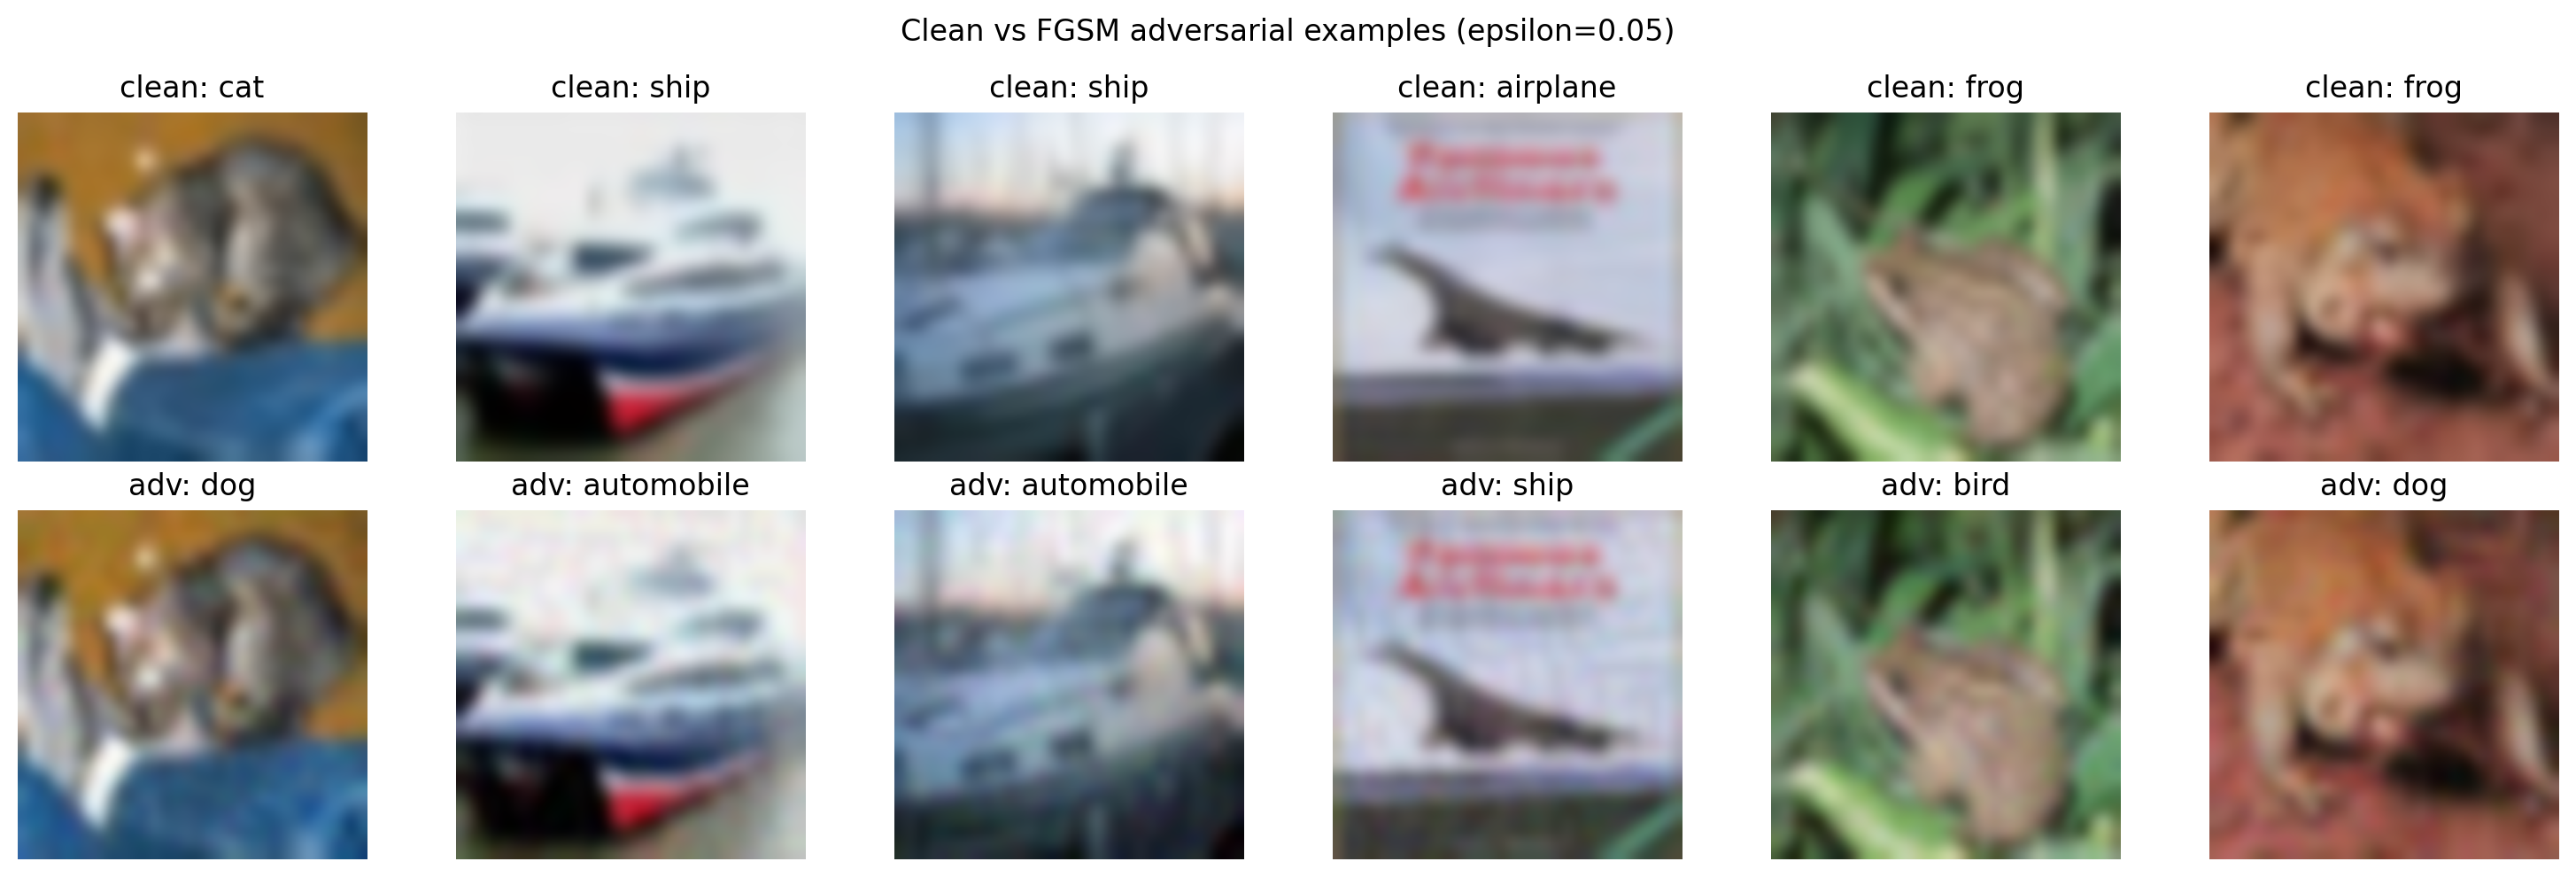

In [15]:
def denormalize(img_tensor):
    # Undo Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)): [-1,1] -> [0,1] for display.
    return (img_tensor * 0.5 + 0.5).clamp(0, 1)

n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5), dpi=200)  # row 0: clean, row 1: adversarial

class_names = id_test.classes  # CIFAR-10 class names, e.g. ['airplane', 'automobile', ...]

for i in range(n_show):
    img_clean = denormalize(x_clean[i]).cpu().permute(1, 2, 0)   # (C,H,W) -> (H,W,C) for imshow
    img_adv = denormalize(x_adv[i]).cpu().permute(1, 2, 0)

    axes[0, i].imshow(img_clean, interpolation="bicubic")
    axes[0, i].set_title(f"clean: {class_names[clean_preds[i]]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_adv, interpolation="bicubic")
    axes[1, i].set_title(f"adv: {class_names[adv_preds[i]]}")
    axes[1, i].axis("off")

plt.suptitle(f"Clean vs FGSM adversarial examples (epsilon={epsilon})")
plt.tight_layout()
plt.show()

epsilon=0.000 -> adversarial accuracy: 0.8256
epsilon=0.010 -> adversarial accuracy: 0.5286
epsilon=0.020 -> adversarial accuracy: 0.3098
epsilon=0.050 -> adversarial accuracy: 0.0764
epsilon=0.100 -> adversarial accuracy: 0.0467
epsilon=0.150 -> adversarial accuracy: 0.0561
epsilon=0.200 -> adversarial accuracy: 0.0628
epsilon=0.300 -> adversarial accuracy: 0.0775


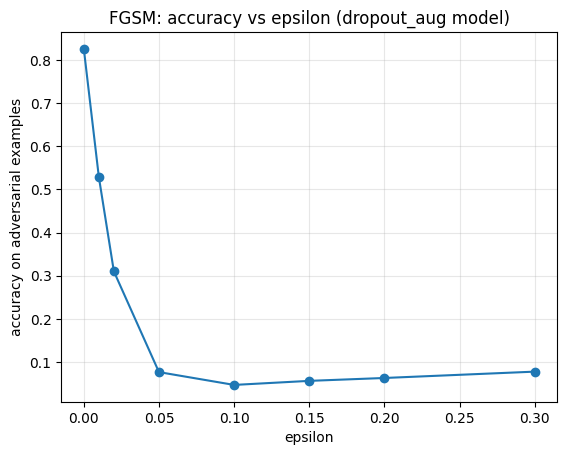

In [16]:
# --- Quantitative: accuracy vs epsilon, over the whole test set ---
epsilons = [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]   # sweep from "no attack" to a strong one

def evaluate_fgsm_at_epsilon(model, data_loader, epsilon):
    correct, total = 0, 0
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        x_adv = x if epsilon == 0.0 else fgsm_attack(model, x, y, epsilon)  # eps=0 -> no perturbation
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total   # accuracy over the WHOLE loader, not just one batch

accuracies = []
for eps in epsilons:
    acc = evaluate_fgsm_at_epsilon(attack_model, id_test_loader, eps)
    accuracies.append(acc)
    print(f"epsilon={eps:.3f} -> adversarial accuracy: {acc:.4f}")

plt.plot(epsilons, accuracies, marker="o")
plt.xlabel("epsilon")
plt.ylabel("accuracy on adversarial examples")
plt.title("FGSM: accuracy vs epsilon (dropout_aug model)")
plt.grid(True, alpha=0.3)
plt.show()

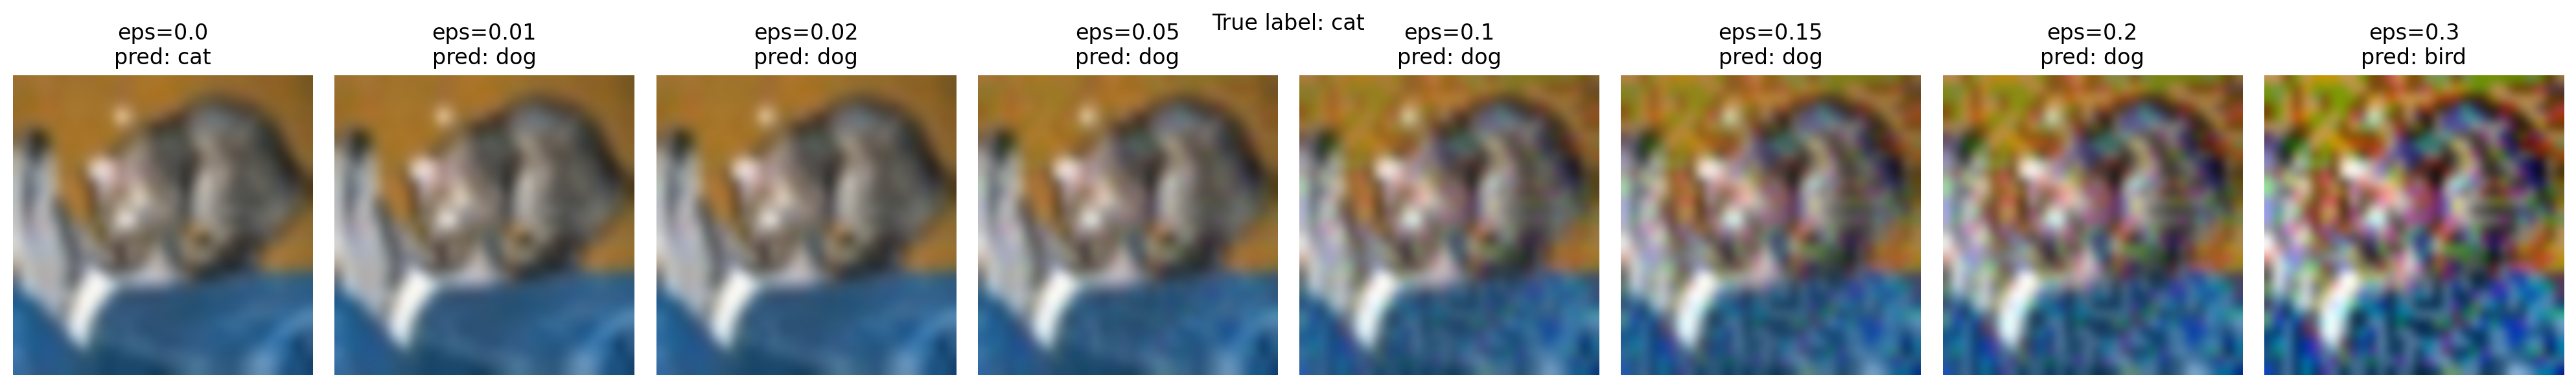

In [17]:
# --- Qualitative: same image, increasing epsilon ---
# Complements the plot above: shows *how* the image visibly degrades
# alongside the accuracy drop, not just the number.
img_idx = 0                                   # just the first image of the batch
x_single = x_clean[img_idx:img_idx + 1]        # keep the batch dim (shape [1,C,H,W]), not [C,H,W]
y_single = y_clean[img_idx:img_idx + 1]

fig, axes = plt.subplots(1, len(epsilons), figsize=(2.5 * len(epsilons), 3), dpi=200)
for ax, eps in zip(axes, epsilons):
    x_e = x_single if eps == 0.0 else fgsm_attack(attack_model, x_single, y_single, eps)
    with torch.no_grad():
        pred = attack_model(x_e).argmax(dim=1).item()
    ax.imshow(denormalize(x_e[0]).cpu().permute(1, 2, 0), interpolation="bicubic")
    ax.set_title(f"eps={eps}\npred: {class_names[pred]}")
    ax.axis("off")
plt.suptitle(f"True label: {class_names[y_single.item()]}")
plt.tight_layout()
plt.show()

**Exercise 2.1 notes:** clean accuracy on this model is ~83% (epsilon=0),
and collapses sharply for even small perturbations (52.9% at eps=0.01, 7.6%
at eps=0.05) -- FGSM needs only an imperceptible perturbation to fool most
of the test set. Accuracy reaches its minimum around eps=0.1 and rises
slightly for larger epsilon: this is a known property of FGSM, a single-step
attack based on a linear approximation of the loss surface around the clean
input -- for very large epsilon that approximation breaks down, so the
computed perturbation is no longer locally optimal, and the attack becomes
slightly less effective (one motivation for iterative attacks like PGD,
which recompute the gradient at each step instead of relying on a single
linear step).

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [18]:
# --- Exercise 2.2: on-the-fly adversarial training ---

def train_cnn_adversarial(train_loader, dropout: bool, epsilon: float = 0.05,
                           epochs: int = 100, lr: float = 1e-4):
    """
    Same training loop as train_cnn, but each batch is augmented with an
    FGSM adversarial version of itself, generated using the model's CURRENT
    weights at that point in training (not a fixed pretrained model) --
    this is what "on the fly" means: as the model changes, so do the
    adversarial examples it's trained against.
    """
    model = CNN(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # Generate adversarial counterparts using the model's CURRENT
            # weights -- this is what "on the fly" means: the attack
            # changes epoch by epoch as the model itself changes.
            x_adv = fgsm_attack(model, x, y, epsilon)

            # Concatenate clean and adversarial versions into one batch,
            # each paired with the SAME true label.
            x_combined = torch.cat([x, x_adv], dim=0)
            y_combined = torch.cat([y, y], dim=0)

            optimizer.zero_grad()
            logits = model(x_combined)
            loss = criterion(logits, y_combined)   # single loss over clean + adversarial together
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in id_val_loader:          # validation accuracy on CLEAN images only
                    x, y = x.to(device), y.to(device)
                    preds = model(x).argmax(dim=1)
                    correct += (preds == y).sum().item()
                    total += y.size(0)
            val_acc = correct / total
            train_loss = running_loss / len(train_loader)
            history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_acc": val_acc})
            print(f"Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val acc: {val_acc:.4f}")

    return model, history

In [19]:
def get_adversarial_model(train_loader, dropout: bool, checkpoint_path: str,
                            epsilon: float = 0.05, epochs: int = 100, lr: float = 1e-4):
    """
    Same load-or-train-and-cache pattern as get_model, but using
    train_cnn_adversarial instead of train_cnn.
    """
    model = CNN(dropout=dropout)
    history_path = checkpoint_path.replace(".pth", "_history.json")

    if os.path.exists(checkpoint_path):
        print(f"Found existing checkpoint at {checkpoint_path}, loading it.")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model = model.to(device)
        if os.path.exists(history_path):
            with open(history_path) as f:
                history = json.load(f)
            for h in history:
                print(f"Epoch {h['epoch']}/{epochs} - train loss: {h['train_loss']:.4f} - val acc: {h['val_acc']:.4f}")
    else:
        print(f"No checkpoint found at {checkpoint_path}, training from scratch (adversarial).")
        model, history = train_cnn_adversarial(train_loader, dropout=dropout, epsilon=epsilon, epochs=epochs, lr=lr)
        torch.save(model.state_dict(), checkpoint_path)
        with open(history_path, "w") as f:
            json.dump(history, f)

    return model


# Adversarially-trained variant of the model already picked as best overall
# in Exercise 1 (dropout + augmentation) -- isolating adversarial training
# as the ONLY new variable relative to cnn_dropout_aug.
cnn_adv_trained = get_adversarial_model(
    id_train_loader_aug,
    dropout=True,
    checkpoint_path="checkpoints/cnn_adv_trained.pth",
    epsilon=0.05,     # same value used throughout Exercise 2.1's evaluation, for consistency
    epochs=100,
)

Found existing checkpoint at checkpoints/cnn_adv_trained.pth, loading it.
Epoch 10/100 - train loss: 1.6898 - val acc: 0.4852
Epoch 20/100 - train loss: 1.5225 - val acc: 0.5840
Epoch 30/100 - train loss: 1.4305 - val acc: 0.6090
Epoch 40/100 - train loss: 1.3576 - val acc: 0.6532
Epoch 50/100 - train loss: 1.2958 - val acc: 0.6808
Epoch 60/100 - train loss: 1.2481 - val acc: 0.6948
Epoch 70/100 - train loss: 1.2074 - val acc: 0.7064
Epoch 80/100 - train loss: 1.1740 - val acc: 0.7190
Epoch 90/100 - train loss: 1.1370 - val acc: 0.7248
Epoch 100/100 - train loss: 1.1182 - val acc: 0.7346


[adv_trained] ID scores  -- mean: 0.6641, std: 0.2370
[adv_trained] OOD scores -- mean: 0.4763, std: 0.1781


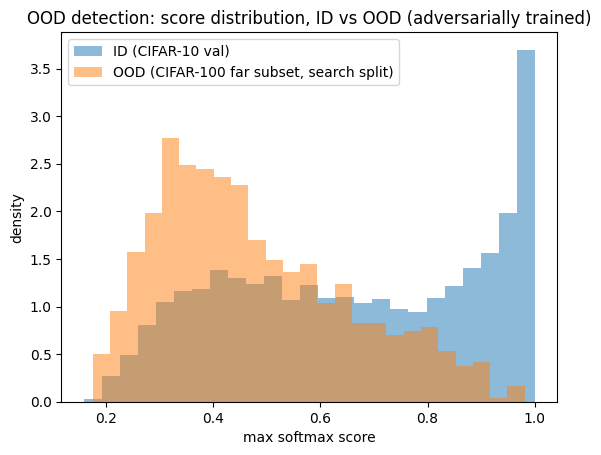

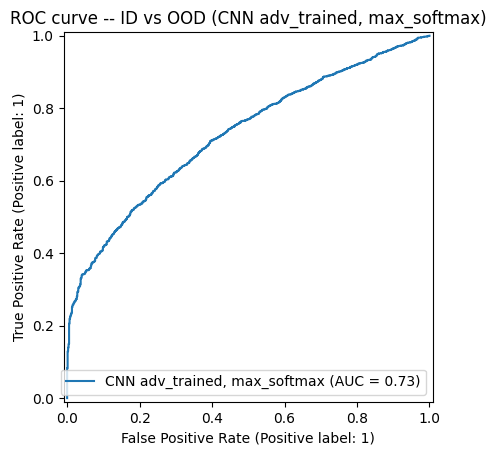

[CNN adv_trained, max_softmax] AUROC: 0.7270


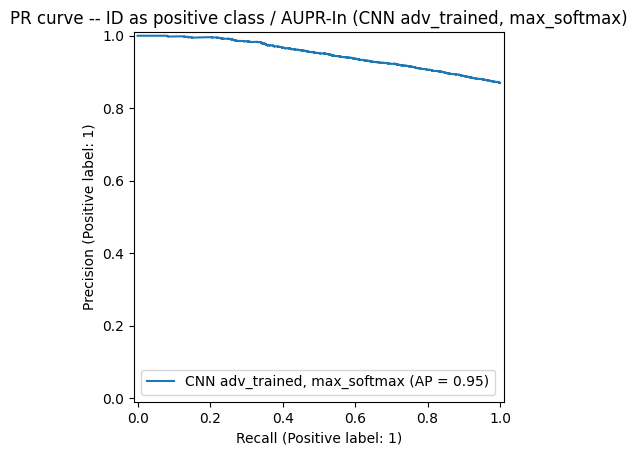

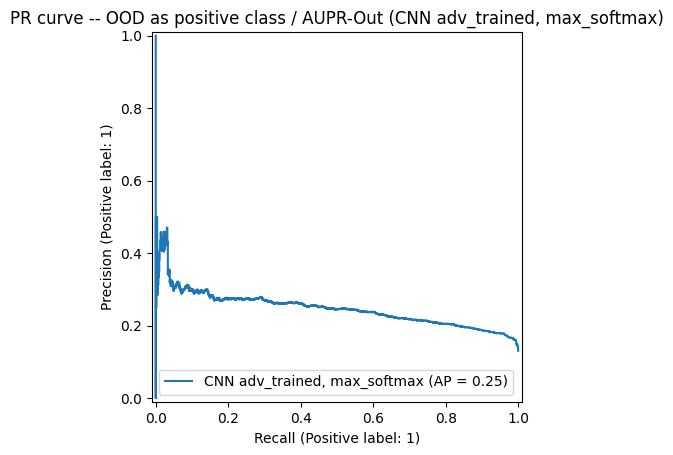

In [20]:
# --- Exercise 2.2: re-evaluate OOD detection on the adversarially-trained model ---
# Comparison step (adv_trained vs. dropout_aug, see next cell) -- uses the
# same id_val + ood_search pairing as every other comparison in this
# notebook, consistent with Exercise 1's search/final split.

cnn_adv_trained.dropout = False  # disable stochastic dropout for standard single-pass eval

id_scores_adv = compute_scores(id_val_loader, max_softmax, cnn_adv_trained)
ood_scores_adv = compute_scores(ood_search_loader, max_softmax, cnn_adv_trained)
scores["adv_trained"] = (id_scores_adv, ood_scores_adv)  # extend the SAME dict used throughout Exercise 1

print(f"[adv_trained] ID scores  -- mean: {id_scores_adv.mean():.4f}, std: {id_scores_adv.std():.4f}")
print(f"[adv_trained] OOD scores -- mean: {ood_scores_adv.mean():.4f}, std: {ood_scores_adv.std():.4f}")

plt.hist(id_scores_adv.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 val)")
plt.hist(ood_scores_adv.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset, search split)")
plt.xlabel("max softmax score")
plt.ylabel("density")
plt.legend()
plt.title("OOD detection: score distribution, ID vs OOD (adversarially trained)")
plt.show()

evaluate_ood_detection(id_scores_adv, ood_scores_adv, label="CNN adv_trained, max_softmax")

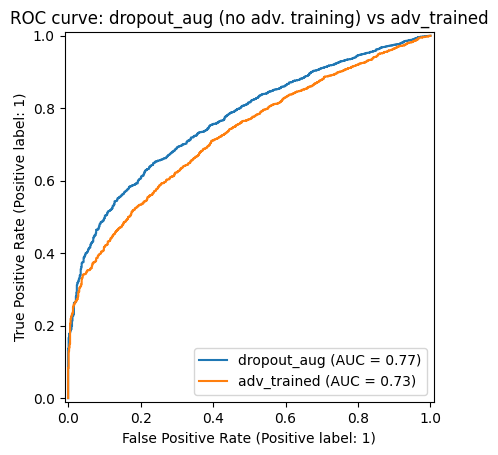

In [21]:
# --- Comparison: adversarially-trained model vs the best model from Exercise 1 ---
# Comparing ONLY these two (not all models at once) isolates a single
# variable -- adversarial training on/off -- since adv_trained starts from
# the exact same configuration (dropout + augmentation, same epochs) as
# dropout_aug.
fig, ax = plt.subplots()
for name in ["dropout_aug", "adv_trained"]:   # ONLY these two: isolates the adversarial-training variable
    id_s, ood_s = scores[name]
    y_true = np.concatenate([np.ones(len(id_s)), np.zeros(len(ood_s))])
    y_score = np.concatenate([id_s.cpu().numpy(), ood_s.cpu().numpy()])
    RocCurveDisplay.from_predictions(y_true, y_score, name=name, ax=ax)   # ax=ax: draw on the SAME axes
plt.title("ROC curve: dropout_aug (no adv. training) vs adv_trained")
plt.show()

[adv_trained] epsilon=0.000 -> adversarial accuracy: 0.7720
[adv_trained] epsilon=0.010 -> adversarial accuracy: 0.7016
[adv_trained] epsilon=0.020 -> adversarial accuracy: 0.6287
[adv_trained] epsilon=0.050 -> adversarial accuracy: 0.4312
[adv_trained] epsilon=0.100 -> adversarial accuracy: 0.2210
[adv_trained] epsilon=0.150 -> adversarial accuracy: 0.1194
[adv_trained] epsilon=0.200 -> adversarial accuracy: 0.0756
[adv_trained] epsilon=0.300 -> adversarial accuracy: 0.0698


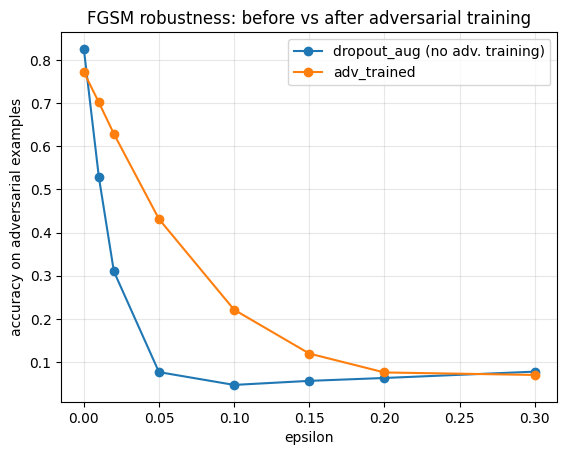

In [22]:
# --- Sanity check: did adversarial training actually improve FGSM robustness? ---
accuracies_adv = []
for eps in epsilons:                                     # reuse the SAME epsilon list from Exercise 2.1
    acc = evaluate_fgsm_at_epsilon(cnn_adv_trained, id_test_loader, eps)
    accuracies_adv.append(acc)
    print(f"[adv_trained] epsilon={eps:.3f} -> adversarial accuracy: {acc:.4f}")

plt.plot(epsilons, accuracies, marker="o", label="dropout_aug (no adv. training)")  # from Exercise 2.1
plt.plot(epsilons, accuracies_adv, marker="o", label="adv_trained")
plt.xlabel("epsilon")
plt.ylabel("accuracy on adversarial examples")
plt.title("FGSM robustness: before vs after adversarial training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Considerations

Adversarial training with on-the-fly FGSM examples (epsilon=0.05) achieved its
primary goal: robustness to FGSM attacks improved dramatically across the
epsilon range that previously caused collapse (e.g. 7.6% -> 43.1% accuracy at
epsilon=0.05, 4.7% -> 22.1% at epsilon=0.10). This came at the cost of a
~6.2pp drop in clean validation accuracy (79.6% -> 73.5%), consistent with
the well-documented accuracy-robustness trade-off of adversarial training.

Re-evaluating OOD detection on the adversarially-trained model, however,
shows a *decrease* in AUROC (0.770 -> 0.727) relative to the non-adversarially
trained model. Both ID and OOD mean confidence scores drop substantially
(ID: 0.850 -> 0.664, OOD: 0.656 -> 0.476), suggesting the model becomes
generally less "peaked" in its softmax outputs after adversarial training --
a known side effect that narrows the gap max-softmax relies on to separate
ID from OOD. This indicates that adversarial robustness (to small, targeted
Lp-bounded perturbations) and improved OOD detection (via a simple
confidence-based score) are not automatically aligned goals: adversarial
training here improved one form of robustness while slightly hurting another.

---
## Exercise 3: Wildcard

You know the drill. Pick *ONE* of the following exercises to complete.

### Exercise 3.1: Implement ODIN for OOD detection
ODIN is a very simple approach, and you can already start experimenting by implementing a temperature hyperparameter in your base model and doing a grid search on $T$ and $\varepsilon$.


In [23]:
# --- Exercise 3.1: ODIN ---

def odin_preprocess(model, x, T, epsilon):
    """
    ODIN input preprocessing: nudge x in the direction that INCREASES the
    model's confidence in its own predicted class (note the MINUS sign,
    opposite of FGSM, which instead maximizes the loss to fool the model).
    Uses the model's own prediction as pseudo-label, since no ground truth
    is available at OOD-detection time.
    """
    x = x.clone().detach().to(device)
    x.requires_grad_(True)

    logits = model(x) / T                          # temperature-scaled logits
    pseudo_label = logits.argmax(dim=1).detach()    # model's OWN prediction, used as pseudo ground truth
    loss = F.cross_entropy(logits, pseudo_label)     # how far the model is from 100% sure of this

    model.zero_grad()
    loss.backward()                                    # populates x.grad

    x_odin = x - epsilon * x.grad.sign()   # MINUS: move to DECREASE this loss (increase confidence)
    x_odin = torch.clamp(x_odin, min=-1.0, max=1.0)
    return x_odin.detach()


def compute_odin_scores(data_loader, model, T, epsilon):
    """Analogous to compute_scores, but using the full ODIN pipeline (perturb
    the input first, then score with temperature-scaled softmax)."""
    scores = []
    model.eval()
    for x, y in data_loader:                        # y unused: ODIN never needs true labels
        x = x.to(device)
        x_odin = odin_preprocess(model, x, T, epsilon)   # step 1: perturb toward higher confidence
        with torch.no_grad():
            logits = model(x_odin) / T                    # step 2: re-score the PERTURBED image
            s = F.softmax(logits, dim=1).max(dim=1)[0]
        scores.append(s)
    return torch.cat(scores)

In [24]:
# --- Grid search over T and epsilon ---
# T is swept on a log scale (1, 10, 100, 1000): temperature scaling's effect
# on the softmax shape is multiplicative, not additive. epsilon
# is swept over a much smaller, finer range than FGSM's, since ODIN's
# perturbation is meant to be a small nudge toward confidence, not an attack.
# NOTE: this is the hyperparameter SEARCH step -- id_val + ood_search only.
# id_test + ood_final are reserved for the final evaluation below, once
# (T, epsilon) has been picked, so that AUROC isn't reported on the exact
# data used to choose them.
odin_model = cnn_dropout_aug
odin_model.dropout = False

T_values = [1, 10, 100, 1000]                          # log-spaced: temperature's effect is multiplicative
epsilon_values = [0.0, 0.0005, 0.001, 0.002, 0.005]     # small values: a gentle nudge, not an attack

best_auroc = 0.0
best_T, best_eps = None, None
grid_results = []                                        # keeps every (T, eps, auroc) triple for reference

for T in T_values:
    for eps in epsilon_values:
        id_s = compute_odin_scores(id_val_loader, odin_model, T, eps)
        ood_s = compute_odin_scores(ood_search_loader, odin_model, T, eps)

        y_true = np.concatenate([np.ones(len(id_s)), np.zeros(len(ood_s))])
        y_score = np.concatenate([id_s.cpu().numpy(), ood_s.cpu().numpy()])
        auroc = roc_auc_score(y_true, y_score)

        grid_results.append({"T": T, "epsilon": eps, "auroc": auroc})
        print(f"T={T:>4} eps={eps:.4f} -> AUROC: {auroc:.4f}")

        if auroc > best_auroc:            # track the single best (T, epsilon) seen so far
            best_auroc = auroc
            best_T, best_eps = T, eps

print(f"\nBest on search split: T={best_T}, epsilon={best_eps}, AUROC={best_auroc:.4f}")
print("(plain max_softmax on the same model/search split, for reference: see Exercise 1's dropout_aug row above)")

T=   1 eps=0.0000 -> AUROC: 0.7695
T=   1 eps=0.0005 -> AUROC: 0.7717
T=   1 eps=0.0010 -> AUROC: 0.7735
T=   1 eps=0.0020 -> AUROC: 0.7760
T=   1 eps=0.0050 -> AUROC: 0.7799
T=  10 eps=0.0000 -> AUROC: 0.8164
T=  10 eps=0.0005 -> AUROC: 0.8178
T=  10 eps=0.0010 -> AUROC: 0.8190
T=  10 eps=0.0020 -> AUROC: 0.8212
T=  10 eps=0.0050 -> AUROC: 0.8255
T= 100 eps=0.0000 -> AUROC: 0.8194
T= 100 eps=0.0005 -> AUROC: 0.8207
T= 100 eps=0.0010 -> AUROC: 0.8221
T= 100 eps=0.0020 -> AUROC: 0.8243
T= 100 eps=0.0050 -> AUROC: 0.8294
T=1000 eps=0.0000 -> AUROC: 0.8196
T=1000 eps=0.0005 -> AUROC: 0.8210
T=1000 eps=0.0010 -> AUROC: 0.8223
T=1000 eps=0.0020 -> AUROC: 0.8246
T=1000 eps=0.0050 -> AUROC: 0.8297

Best on search split: T=1000, epsilon=0.005, AUROC=0.8297
(plain max_softmax on the same model/search split, for reference: see Exercise 1's dropout_aug row above)


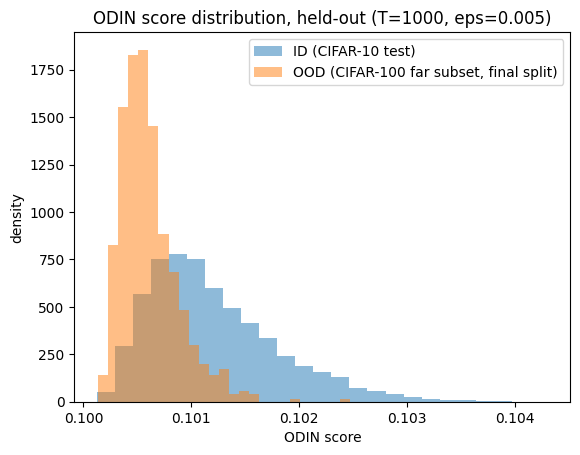

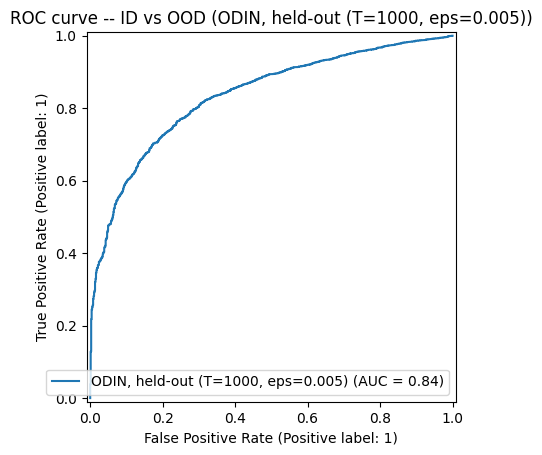

[ODIN, held-out (T=1000, eps=0.005)] AUROC: 0.8351


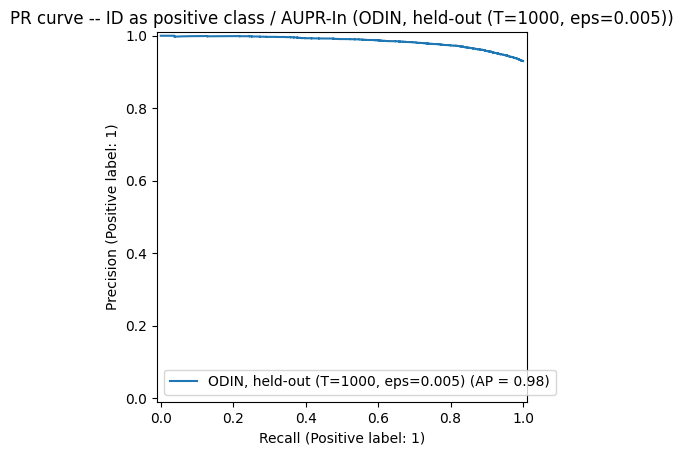

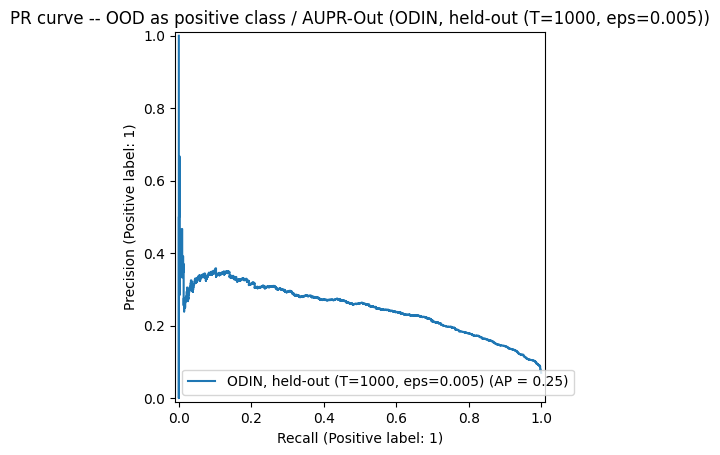

In [25]:
# --- Final evaluation at the best (T, epsilon) found ---
# CORRECTION: (T, epsilon) were chosen above specifically to maximize AUROC
# on id_val + ood_search. Re-evaluating on that same pair would report an
# optimistically biased number (the search literally optimized for it). This
# cell instead evaluates ONCE on id_test + ood_final -- data that played no
# role in the grid search -- for the honest final AUROC.
id_scores_odin = compute_odin_scores(id_test_loader, odin_model, best_T, best_eps)
ood_scores_odin = compute_odin_scores(ood_final_loader, odin_model, best_T, best_eps)
scores["odin_best"] = (id_scores_odin, ood_scores_odin)   # extend the shared scores dict once more

plt.hist(id_scores_odin.cpu(), density=True, alpha=0.5, bins=25, label="ID (CIFAR-10 test)")
plt.hist(ood_scores_odin.cpu(), density=True, alpha=0.5, bins=25, label="OOD (CIFAR-100 far subset, final split)")
plt.xlabel("ODIN score")
plt.ylabel("density")
plt.legend()
plt.title(f"ODIN score distribution, held-out (T={best_T}, eps={best_eps})")
plt.show()

evaluate_ood_detection(id_scores_odin, ood_scores_odin,
                        label=f"ODIN, held-out (T={best_T}, eps={best_eps})")

## Considerations

ODIN improves OOD detection substantially over plain max-softmax (AUROC:
0.770 -> 0.830 on the search split, confirmed at 0.835 held-out). The grid
search shows the two components of ODIN contribute very unevenly: temperature
scaling drives almost the entire improvement (T=1 -> T=10 alone: 0.770 ->
0.816), while further increasing T saturates quickly (T=10, 100, 1000 are
all within ~0.003 AUROC of each other at epsilon=0) -- T=10 is therefore the
practical choice, not the literal grid maximum (T=1000), since the
difference is within noise. Input perturbation adds a smaller, but
consistent, additional gain (~0.01 AUROC at every T).

This result directly confirms the hypothesis raised in Exercise 1: plain
max-softmax saturates near 1.0 even for OOD inputs, compressing the
separation between ID and OOD scores. Temperature scaling counteracts
exactly this saturation, revealing logit-magnitude differences between ID
and OOD that were otherwise hidden -- explaining why it is the dominant
factor in ODIN's improvement here.

All the numbers above come from `id_val` + `ood_search` -- the same data the
grid search optimized `best_T`/`best_eps` over -- so they describe how well
the search *could* do, not an unbiased estimate for unseen data. The cell
above evaluates the chosen (T=1000, epsilon=0.005) once more on `id_test` +
`ood_final`, giving AUROC=0.835 as the honest final number. It tracks the
search-split best (0.830) closely -- if anything slightly higher -- so
despite the grid search trying 20 configurations, the selected
hyperparameters don't show obvious overfitting to the search split in this
run.

---

### Exercise 3.2: Implement JARN
In exercise 2.2 you already implemented Jacobian-regularized learning to make your model more robust to adversarial samples. Add a *discriminator* to your model to encourage the adversarial samples used for regularization to be more *salient*.

See [the JARN paper](https://arxiv.org/abs/1912.10185) for more details.

---

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.

---
---